# Experimento 4 — Comparativa de Herramientas de Anotación

Compara el rendimiento del modelo v1 (9 aug) y v2 (15 aug) en las tres herramientas:

| Herramienta       | Tipo de anotación       |
|:------------------|:------------------------|
| Label Studio      | Automática              |
| CVAT              | Visual manual           |
| ELAN              | Lingüística             |

**Objetivo:** Medir cómo el tipo de anotación afecta la accuracy del mismo modelo. Evidencia directa de la influencia del etiquetado (objetivo 3 de la tesis).

**Prerequisito:** `exp1_ab_pipeline.py`, `modelo/entrenar.py` y `07_extraer_keypoints.py` ejecutados.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report

sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from utils.config import (N_FRAMES, N_KEYPOINTS, DATA_DIR, SPLIT_PATH, CSV_TOP35,
                           KEYPOINTS_DIR)
from utils.preprocessing import normalizar_hombros
from utils.data_io import cargar_herramienta_comparativa

MODELOS_DIR = os.path.join(DATA_DIR, "modelo")
EXP_AB_DIR  = os.path.join(DATA_DIR, "experimentos", "exp1_ab", "salidas")
SALIDA_DIR  = os.path.join(DATA_DIR, "experimentos", "exp4_herramientas", "salidas")
os.makedirs(SALIDA_DIR, exist_ok=True)

print(f"Modelos v2: {MODELOS_DIR}")
print(f"Salida:     {SALIDA_DIR}")

## Cargar modelos

In [2]:
def cargar_modelo(path, nombre):
    if not os.path.exists(path):
        print(f"  [AVISO] Modelo no encontrado: {path}"); return None
    print(f"  Cargando {nombre}...")
    return tf.keras.models.load_model(path)

model_v2 = cargar_modelo(os.path.join(MODELOS_DIR, 'mejor_modelo_v2.keras'), 'v2 (15 aug)')
model_v1 = cargar_modelo(os.path.join(EXP_AB_DIR,  'modelo_B.h5'),           'v1 (9 aug)')

if model_v2 is None:
    raise FileNotFoundError("[ERROR] Ejecuta modelo/entrenar.py primero")

  Cargando v2 (15 aug)...


  Cargando v1 (9 aug)...


## Preparar datos de evaluación

In [3]:
split    = np.load(SPLIT_PATH, allow_pickle=True)
idx_test = split['idx_test'].tolist()

df_top35  = pd.read_csv(CSV_TOP35)
clases    = sorted(df_top35['glosa'].unique())
idx_map   = {c: i for i, c in enumerate(clases)}
n_clases  = len(clases)

# Label Studio (test set fijo)
X_all, y_all = [], []
for _, row in df_top35.iterrows():
    npy = os.path.join(KEYPOINTS_DIR, f"{row['video_id']}.npy")
    if not os.path.exists(npy): continue
    kp = np.load(npy)
    if kp.shape != (N_FRAMES, N_KEYPOINTS): continue
    X_all.append(kp); y_all.append(idx_map.get(row['glosa'], -1))
X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.int32)
X_ls  = np.array([normalizar_hombros(X_all[i]) for i in idx_test], dtype=np.float32)
y_ls  = y_all[idx_test]

# CVAT y ELAN
X_cvat, y_cvat = cargar_herramienta_comparativa("cvat", idx_map)
X_elan, y_elan = cargar_herramienta_comparativa("elan", idx_map)
if len(X_cvat) == 0: X_cvat = y_cvat = None
if len(X_elan) == 0: X_elan = y_elan = None

print(f"Label Studio: {len(X_ls)} | CVAT: {len(X_cvat) if X_cvat is not None else 0} | ELAN: {len(X_elan) if X_elan is not None else 0}")

Label Studio: 35 | CVAT: 34 | ELAN: 34


## Evaluación por herramienta

In [4]:
def evaluar(model, X, y, nombre_h, nombre_m):
    if model is None or X is None or len(X) == 0: return None
    pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y, pred)
    print(f"  [{nombre_m}] {nombre_h:<26} {acc*100:.1f}%  ({len(X)} videos)")
    return acc, pred

herramientas = [
    ('Label Studio (automático)', X_ls,   y_ls),
    ('CVAT (visual manual)',       X_cvat, y_cvat),
    ('ELAN (lingüístico)',         X_elan, y_elan),
]

registros = []
for nombre_h, X, y in herramientas:
    if X is None or len(X) == 0:
        print(f"\n{nombre_h}: sin datos"); continue

    print(f"\n{'='*50}\n{nombre_h}\n{'='*50}")
    res_v2 = evaluar(model_v2, X, y, nombre_h, 'v2')
    res_v1 = evaluar(model_v1, X, y, nombre_h, 'v1') if model_v1 else None

    acc_v2, pred_v2 = res_v2 if res_v2 else (None, None)
    acc_v1          = res_v1[0] if res_v1 else None

    if pred_v2 is not None and nombre_h == 'Label Studio (automático)':
        print(f"\nReporte por seña — {nombre_h} (v2):")
        print(classification_report(y, pred_v2, labels=list(range(n_clases)),
                                     target_names=clases, zero_division=0))

    registros.append({
        'herramienta': nombre_h,
        'acc_v1_9aug':  round(acc_v1, 4) if acc_v1 else None,
        'acc_v2_15aug': round(acc_v2, 4) if acc_v2 else None,
        'mejora_pp':    round((acc_v2 - acc_v1)*100, 2) if (acc_v1 and acc_v2) else None,
        'n_videos':     len(X),
    })


Label Studio (automático)


  [v2] Label Studio (automático)  42.9%  (35 videos)


  [v1] Label Studio (automático)  42.9%  (35 videos)

Reporte por seña — Label Studio (automático) (v2):
                     precision    recall  f1-score   support

            ABAJO_2       0.50      1.00      0.67         1
          ACCIDENTE       0.50      1.00      0.67         1
           ACOMODAR       0.50      1.00      0.67         1
           AH,CLARO       0.50      1.00      0.67         1
             ALGUNO       0.00      0.00      0.00         1
            APROBAR       0.50      1.00      0.67         1
          AUDIENCIA       0.00      0.00      0.00         1
  AUDIOLOGÍA+AGENTE       0.00      0.00      0.00         1
         AVERGONZAR       0.50      1.00      0.67         1
              AVISO       0.00      0.00      0.00         1
         BALONCESTO       0.00      0.00      0.00         1
             BORRAR       0.00      0.00      0.00         1
               BOTE       1.00      1.00      1.00         1
           CORRECTO       1.00      1.00

  [v1] CVAT (visual manual)       23.5%  (34 videos)

ELAN (lingüístico)
  [v2] ELAN (lingüístico)         17.6%  (34 videos)


  [v1] ELAN (lingüístico)         14.7%  (34 videos)


## Tabla comparativa final

In [5]:
def pct(v):
    return f"{v*100:.1f} %".replace(".", ",") if v else "N/A"

# Tabla limpia en % impresa en el mismo paso (lista para captura)
print("="*70)
print("  EXACTITUD POR HERRAMIENTA DE ANOTACIÓN (v1 vs v2)")
print("="*70)
print(f"  {'Herramienta':<28}{'v1 (9 téc.)':>12}{'v2 (15 téc.)':>14}{'Mejora':>10}")
print("  " + "-"*64)
for r in registros:
    dif = f"{r['mejora_pp']:+.1f} pp".replace(".", ",") if r['mejora_pp'] is not None else ""
    print(f"  {r['herramienta']:<28}{pct(r['acc_v1_9aug']):>12}"
          f"{pct(r['acc_v2_15aug']):>14}{dif:>10}")
print("="*70)

# Guardar CSV (valores numéricos) y mostrar DataFrame en % en la notebook
df_res = pd.DataFrame(registros)
df_res.to_csv(os.path.join(SALIDA_DIR, 'comparativa_herramientas_v1_v2.csv'),
              index=False, encoding='utf-8-sig')
print(f"\nResultados guardados en: {SALIDA_DIR}")

df_pct = df_res.copy()
for c in ['acc_v1_9aug', 'acc_v2_15aug']:
    df_pct[c] = df_pct[c].apply(pct)
df_pct

  EXACTITUD POR HERRAMIENTA DE ANOTACIÓN (v1 vs v2)
  Herramienta                  v1 (9 téc.)  v2 (15 téc.)    Mejora
  ----------------------------------------------------------------
  Label Studio (automático)         42,9 %        42,9 %   +0,0 pp
  CVAT (visual manual)              23,5 %        41,2 %  +17,6 pp
  ELAN (lingüístico)                14,7 %        17,6 %   +2,9 pp

Resultados guardados en: C:\Users\dell\Documents\TIC\Codigo_TIC\experimentos\exp4_herramientas


,herramienta,acc_v1_9aug,acc_v2_15aug,mejora_pp,n_videos
0,Label Studio (automático),"42,9 %","42,9 %",0.00,35
1,CVAT (visual manual),"23,5 %","41,2 %",17.65,34
2,ELAN (lingüístico),"14,7 %","17,6 %",2.94,34


## Visualización

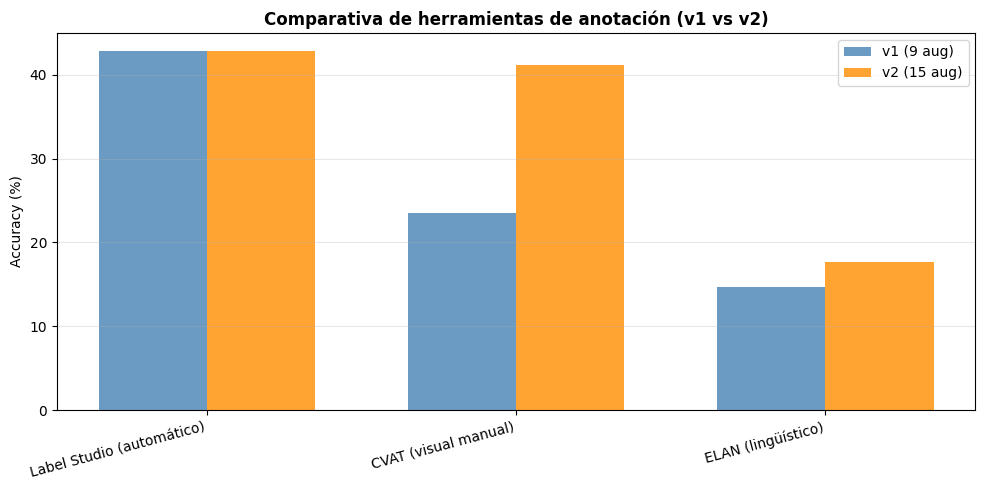

In [6]:
import matplotlib.pyplot as plt

df_plot = df_res.dropna(subset=['acc_v2_15aug'])

x = range(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
if 'acc_v1_9aug' in df_plot.columns and df_plot['acc_v1_9aug'].notna().any():
    ax.bar([i - width/2 for i in x], df_plot['acc_v1_9aug']*100, width,
           label='v1 (9 aug)', color='steelblue', alpha=0.8)
ax.bar([i + width/2 for i in x], df_plot['acc_v2_15aug']*100, width,
       label='v2 (15 aug)', color='darkorange', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['herramienta'], rotation=15, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparativa de herramientas de anotación (v1 vs v2)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SALIDA_DIR, 'comparativa_herramientas.png'), dpi=150)
plt.show()